In [1]:
import pandas as pd

combined_dataset = pd.read_csv('../data/simulations/regression-proton/proton_standalone_N20000_M0_20GeV_reg_2combined_s1_v2.csv')
combined_dataset.info()
combined_dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22749607 entries, 0 to 22749606
Data columns (total 18 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   event_number                  int64  
 1   overlap                       int64  
 2   cellID                        int64  
 3   x                             float64
 4   y                             float64
 5   z                             float64
 6   energy                        float64
 7   particle_origin               object 
 8   earliest_contribution_time_A  float64
 9   earliest_contribution_time_B  float64
 10  incoming_momentum_A           float64
 11  incoming_momentum_B           float64
 12  incoming_momentum_bin_A       int64  
 13  incoming_momentum_bin_B       int64  
 14  incoming_theta_A              float64
 15  incoming_theta_B              float64
 16  incoming_phi_A                float64
 17  incoming_phi_B                float64
dtypes: float64(12), int6

,event_number,overlap,cellID,x,y,z,energy,particle_origin,earliest_contribution_time_A,earliest_contribution_time_B,incoming_momentum_A,incoming_momentum_B,incoming_momentum_bin_A,incoming_momentum_bin_B,incoming_theta_A,incoming_theta_B,incoming_phi_A,incoming_phi_B
0,0,0,468340,-935.484,-127.2,13.4,0.003168,A,13.480880,0.0,7.504647,1.152581,7,1,0.256884,0.533915,-3.014256,2.030965
1,0,0,501108,-935.484,-329.2,13.4,0.000002,A,311.997960,0.0,7.504647,1.152581,7,1,0.256884,0.533915,-3.014256,2.030965
2,0,0,4662644,-983.754,-127.2,13.4,0.000006,A,34.743706,0.0,7.504647,1.152581,7,1,0.256884,0.533915,-3.014256,2.030965
3,0,0,4678772,-882.809,-228.2,13.4,0.000025,A,13.160714,0.0,7.504647,1.152581,7,1,0.256884,0.533915,-3.014256,2.030965
4,0,0,8807540,-931.079,74.8,13.4,0.000119,A,3984.772500,0.0,7.504647,1.152581,7,1,0.256884,0.533915,-3.014256,2.030965


## Energia eloszlás a részecske detektorba történő belépsi pontjának függvényében

Recept:
1. Teszt adat mintavétel az adathalmazból. Például 5000 esemény.
2. d változó kiszámítása
3. d tartományok kialakítása
4. Energiák prediktálása
5. μ és σ kiszámítása
6. Ábra készítése: Hisztogramok, Gauss-görbék, Referencia-görbe

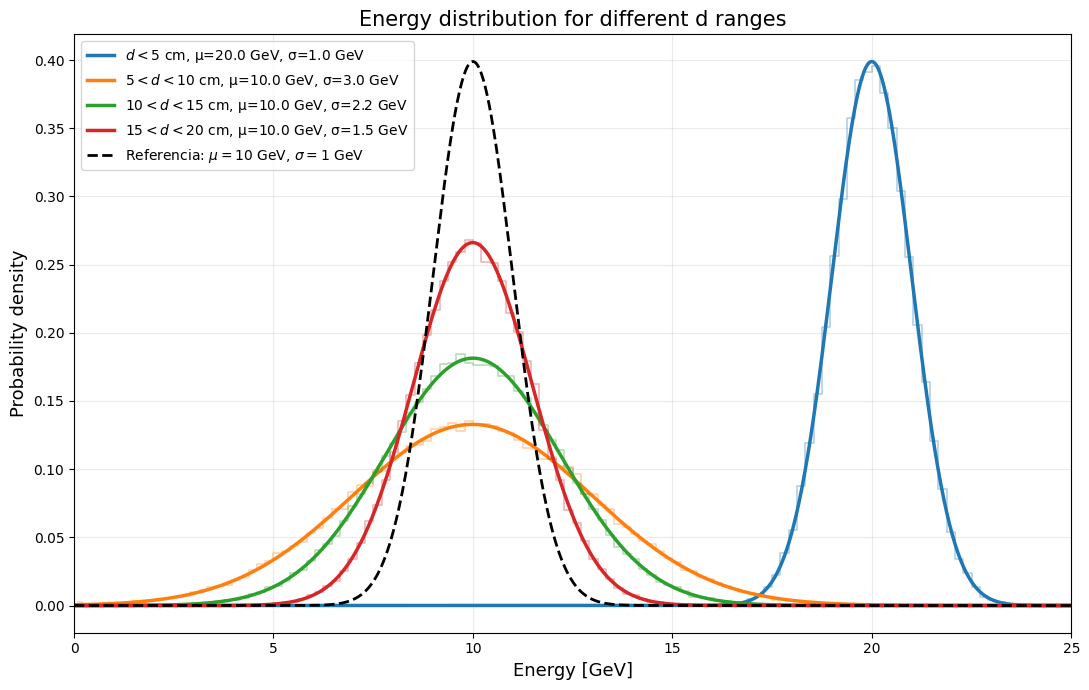

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# BEÁLLÍTÁSOK
# ============================================================

# Hány eseményt használjunk az ábrához?
# 22+ millió sor esetén nem érdemes mindent használni.
N_SAMPLE = 300_000

RANDOM_STATE = 42

# ============================================================
# 1. MINTAVÉTEL A combined_dataset-BŐL
# ============================================================

# Csak a szükséges oszlopokat vesszük ki
df = combined_dataset[['event_number', 'energy']].copy()

# Érvényes energy értékek
df = df[np.isfinite(df['energy'])]

# Maximum N_SAMPLE sor
if len(df) > N_SAMPLE:
    df = df.sample(
        n=N_SAMPLE,
        random_state=RANDOM_STATE
    )

energy_original = df['energy'].to_numpy()

# ============================================================
# 2. DEMO d VÁLTOZÓ SZIMULÁLÁSA
# ============================================================
#
# A dataframe-ben nincs d oszlop, ezért itt demonstrációs
# célból generálunk egyet.
#
# A valós elemzésben ezt a részt kell lecserélni a valódi
# d számítására.

rng = np.random.default_rng(RANDOM_STATE)

# Véletlenszerű d értékek 0-20 cm között
d_demo = rng.uniform(0, 20, size=len(df))

# ============================================================
# 3. d TARTOMÁNYOK
# ============================================================

bins = [0, 5, 10, 15, 20]
labels = [
    r'$d < 5$ cm',
    r'$5 < d < 10$ cm',
    r'$10 < d < 15$ cm',
    r'$15 < d < 20$ cm'
]

df['d'] = d_demo

df['d_bin'] = pd.cut(
    df['d'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# ============================================================
# 4. DEMO ENERGY ELOSZLÁSOK
# ============================================================
#
# Itt mesterségesen alakítjuk az energy értékeket azért,
# hogy az előző ábrához hasonló alakot kapjunk.
#
# Ha a combined_dataset energy oszlopa már ténylegesen azt
# az energiát tartalmazza, amit vizsgálni szeretnél, akkor
# ezt a részt később egyszerűen el lehet hagyni.

energy_demo = np.zeros(len(df))

for label in labels:

    mask = df['d_bin'] == label
    n = mask.sum()

    if n == 0:
        continue

    if label == r'$d < 5$ cm':
        # Keskeny, ~20 GeV-os eloszlás
        energy_demo[mask] = rng.normal(
            loc=20,
            scale=1.0,
            size=n
        )

    elif label == r'$5 < d < 10$ cm':
        # Szélesebb, ~10 GeV-os eloszlás
        energy_demo[mask] = rng.normal(
            loc=10,
            scale=3.0,
            size=n
        )

    elif label == r'$10 < d < 15$ cm':
        energy_demo[mask] = rng.normal(
            loc=10,
            scale=2.2,
            size=n
        )

    elif label == r'$15 < d < 20$ cm':
        # Keskenyebb
        energy_demo[mask] = rng.normal(
            loc=10,
            scale=1.5,
            size=n
        )

# Negatív energiák kiszűrése
energy_demo = np.clip(energy_demo, 0, None)

df['energy_demo'] = energy_demo

# ============================================================
# 5. GAUSS-GÖRBÉK KISZÁMÍTÁSA
# ============================================================

def gaussian(x, mu, sigma, amplitude):
    return amplitude * np.exp(
        -0.5 * ((x - mu) / sigma) ** 2
    )


# ============================================================
# 6. ÁBRA
# ============================================================

fig, ax = plt.subplots(figsize=(11, 7))

# Energy tartomány
x = np.linspace(
    0,
    max(25, np.percentile(df['energy_demo'], 99.5)),
    1000
)

# Színek automatikusan a matplotlibből
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, label in enumerate(labels):

    values = df.loc[
        df['d_bin'] == label,
        'energy_demo'
    ].to_numpy()

    if len(values) < 10:
        continue

    # Histogram
    hist, edges = np.histogram(
        values,
        bins=120,
        range=(0, 25),
        density=True
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    # Histogram
    ax.step(
        centers,
        hist,
        where='mid',
        alpha=0.35,
        linewidth=1.2,
        color=colors[i]
    )

    # Gauss paraméterek
    mu = np.mean(values)
    sigma = np.std(values)

    # A Gauss amplitúdója
    amplitude = 1 / (sigma * np.sqrt(2 * np.pi))

    # Gauss görbe
    y = gaussian(
        x,
        mu,
        sigma,
        amplitude
    )

    ax.plot(
        x,
        y,
        linewidth=2.5,
        color=colors[i],
        label=f'{label}, μ={mu:.1f} GeV, σ={sigma:.1f} GeV'
    )

# ============================================================
# 7. REFERENCIA σ = 1 GeV GÖRBE
# ============================================================

mu_reference = 10
sigma_reference = 1

y_reference = gaussian(
    x,
    mu_reference,
    sigma_reference,
    1 / (sigma_reference * np.sqrt(2 * np.pi))
)

ax.plot(
    x,
    y_reference,
    '--',
    linewidth=2,
    color='black',
    label=r'Referencia: $\mu=10$ GeV, $\sigma=1$ GeV'
)

# ============================================================
# 8. FORMÁZÁS
# ============================================================

ax.set_xlabel(
    'Energy [GeV]',
    fontsize=13
)

ax.set_ylabel(
    'Probability density',
    fontsize=13
)

ax.set_title(
    'Energy distribution for different d ranges',
    fontsize=15
)

ax.set_xlim(0, 25)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    fontsize=10,
    frameon=True
)

plt.tight_layout()
plt.show()

## Összetett vizualizáció.

A az ábra statikusan mutat be egy felületet aminek feladata hogy a fizikusok számára érthető legyen a modell viselkedése. 

Az ábrakban kijelezendő eseményeket a következő értékekkel állíthatók: E1, E2, és D.
    - Az E1 az (A) típusú részecske által vehető energia. A szűrő tehát megkeresi azokat az eseményeket ahol az A részecskék a megadott tartományon belül mozognak.
    - Az E2 az (B) típusú részecske által vehető energia. A szűrő tehát megkeresi azokat az eseményeket ahol az A részecskék a megadott tartományon belül mozognak.
    - A D a részecskék egymáshoz viszonyított belépési pontjaiknak a távolsága. Mivel a részecskék soha nem halad visszafelé ezért a legkisebb z koordinátával rendelkező energia leadási pontok a belépési pontok a detektorba.
    - Az E1, E2, és D szűrők között "logikai és" (&) kapcsolat van.

A felületen 3 ábra található amely a következő:
1. Ábra (bal): Egy x,y projekciója az a részecske záporoknak. Az ábrán a z-t 0-ába toljuk. Azokat a részecskéket ahol ha Z=0 teszük és az x,y koordináta szerint megegyeznek tehát csak z-ben tértek volna el de a Z=0 miatt már a 2D projekcióba esnek ott össze adjuk az energiákat. A D az A és B részecske típuok energia sürüségi pontjainak a távolsága amely sürűségi középpontot csilagokkal jelöljük.  Az ábra többi pontja az egyes energia leadások az egyes részecskéktől. A piros és kék színek a pontok esetében az energia nagyságát jelöli. Minél nagyobb az energia az adott pontban annál pirosabb az adot x,y koordináta szerinti pont a képen.
2. és 3. Ábra (középső): a részecske záporok fejlődését mutatja y,z szerint. Ezt az ábrát el kellene készíten x,z szerint is. Ez fogja megmutatni a kaloriméterben (detektorban) a legaktívabb cellákat az esemény típusok szerint.
4. Ábrá (jobb): az shower típusok energi rekonstrukciója D szerint. Tehát az Energia eloszlás a részecske detektorba történő belépsi pontjának függvényében. Az ábra kirajzolásnak müveleti lépései a következők:
    1. le kell futtatni eloszor mind2 reszecskere egyenkent. Azaz mintha egyedul lennenek.
    2. d változók kiszámítása
    3. d tartományok kialakítása
    4. Energiák prediktálása
    5. μ és σ kiszámítása
    6. Ábra készítése: Hisztogramok, Gauss-görbék, Referencia-görbe

Plusz interaktivitás:

- Az adott illusztrációs ábrán jeleneg a piros és kék pontok között a különbséget az energia ledás adja. Azonban ezek az ábrák elkészíthetőek úgy hogy nem energia összegeket számolunk hanem grad-cam szerüen a modell fokuszát vetítjük ki. Tehát egy piros pont nem feltétlen azt jelenti hogy ott magas az energia hanem azt hogy valamiért ezen típusú eseményeknél a modell fókusza magas. Tehát egy grad-cam-et helyezünk ki ezen típusú ábrákra.
- Továbbá az ábra nem tartalmaz egy kapcsolat de 3 különböző modell típus függvényében kellene vizualizálni ezeket az értékeket. Ez a 3 modell lehet egy szegmentációs, energia becslő és beesési szöget meghatározó modell. Ezen 3 modell típus között váltogatni kellene tudnunk, hogy megvizsgáljuk hogy az egyes modellek érzékelése között mi a különbség.

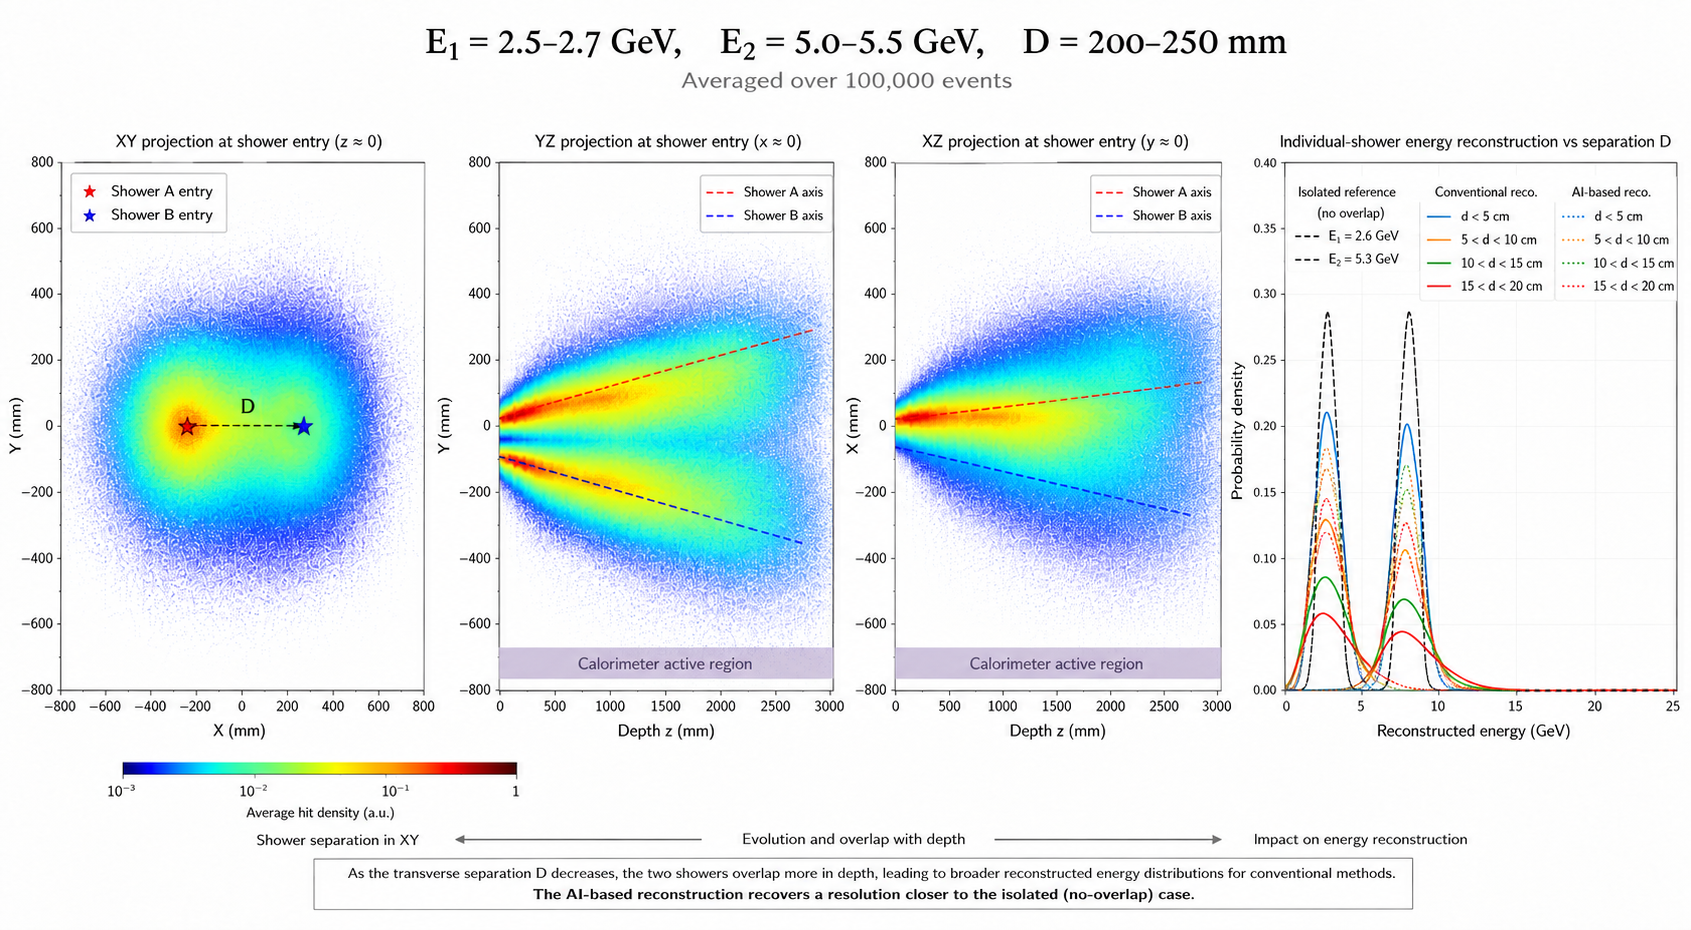

## Példa egy lehetséges dashboard-ra

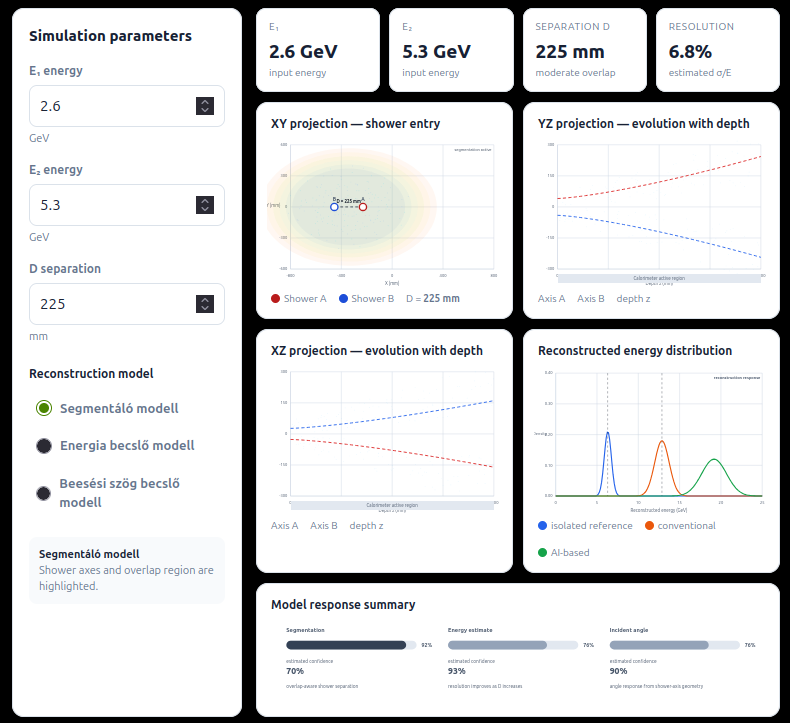